In [218]:
from DeepTemporalClustering import DTC
from sklearn.preprocessing import StandardScaler
from tslearn.datasets import UCR_UEA_datasets
from matplotlib import pyplot as plt
import numpy as np
import tensorflow as tf

In [219]:
from sklearn.model_selection import train_test_split

X_test, y_test,X_train_full, y_train_full,  = UCR_UEA_datasets().load_dataset('CBF')


In [220]:
train_size = int(len(X_train_full) * 0.8)

In [221]:
X_train = X_train_full[:train_size]
y_train = y_train_full[:train_size]

X_val = X_train_full[train_size:]
y_val = y_train_full[train_size:]

In [222]:
noise = np.random.normal(0,0.01,X_train.shape)
X_train_aug = np.concatenate([X_train, X_train + noise])
y_train_aug = np.concatenate([y_train,y_train])

In [223]:
X_train_aug.shape

(1440, 128, 1)

In [224]:
print(f"X_train shape: {X_train.shape}\ny_train shape: {y_train.shape}\nX_val shape: {X_val.shape}\ny_val shape: {y_val.shape}")

X_train shape: (720, 128, 1)
y_train shape: (720,)
X_val shape: (180, 128, 1)
y_val shape: (180,)


In [225]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

n_samples_train, timesteps, n_features = X_train_aug.shape

X_train_scaled = scaler.fit_transform(
    X_train_aug.reshape(-1, n_features)
).reshape(n_samples_train, timesteps, n_features)

X_val_scaled = scaler.transform(
    X_val.reshape(-1, n_features)
).reshape(X_val.shape[0], timesteps, n_features)

X_test_scaled = scaler.transform(
    X_test.reshape(-1, n_features)
).reshape(X_test.shape[0], timesteps, n_features)

In [226]:
from sklearn.pipeline import Pipeline

full_pipeline = Pipeline([
    ("dtc", DTC(n_clusters = 3,input_dim = X_train.shape[2],timesteps=X_train.shape[1])),
])

In [227]:
"""from sklearn.metrics import normalized_mutual_info_score

results = []

for pool_size in [2, 4, 8]:
    for n_units in [[32,1], [50,1], [50,10], [128,63,1]]:
        for kernel_size in [3, 5, 10]:
            modelo = DTC(n_clusters=3, timesteps=X_train.shape[1],
                        pool_size=pool_size, input_dim=X_train.shape[2],
                        n_units=n_units, kernel_size=kernel_size)
            modelo.initialize()
            modelo.pretrain(X_train, epochs=25,batch_size = 32)
            y_pred = modelo.fit(X_train, y_train, X_val, y_val, n_clusters=3)
            nmi = normalized_mutual_info_score(y_train, y_pred)
            results.append({'pool_size': pool_size, 'n_units': n_units,
                          'kernel_size': kernel_size, 'nmi': nmi})
            print(f"pool={pool_size}, units={n_units}, kernel={kernel_size} → NMI={nmi:.4f}")

best = max(results, key=lambda x: x['nmi'])
print("Melhor:", best)"""

'from sklearn.metrics import normalized_mutual_info_score\n\nresults = []\n\nfor pool_size in [2, 4, 8]:\n    for n_units in [[32,1], [50,1], [50,10], [128,63,1]]:\n        for kernel_size in [3, 5, 10]:\n            modelo = DTC(n_clusters=3, timesteps=X_train.shape[1],\n                        pool_size=pool_size, input_dim=X_train.shape[2],\n                        n_units=n_units, kernel_size=kernel_size)\n            modelo.initialize()\n            modelo.pretrain(X_train, epochs=25,batch_size = 32)\n            y_pred = modelo.fit(X_train, y_train, X_val, y_val, n_clusters=3)\n            nmi = normalized_mutual_info_score(y_train, y_pred)\n            results.append({\'pool_size\': pool_size, \'n_units\': n_units,\n                          \'kernel_size\': kernel_size, \'nmi\': nmi})\n            print(f"pool={pool_size}, units={n_units}, kernel={kernel_size} → NMI={nmi:.4f}")\n\nbest = max(results, key=lambda x: x[\'nmi\'])\nprint("Melhor:", best)'

In [266]:
modelo = DTC(n_clusters = 3, timesteps = X_train.shape[1],pool_size = 8,input_dim = X_train.shape[2],kernel_size = 3,n_units = [32,1],n_filters = 16)
modelo.initialize()
modelo.compile(gamma = 0.03,optimizer = 'adam')
modelo.pretrain(X_train_aug,epochs = 25, batch_size = 32)
modelo.fit(X_train_scaled,y_train_aug,X_val_scaled,y_val,n_clusters = 3)

Pretraining...
Epoch 1/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.6089
Epoch 2/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.3760
Epoch 3/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3214
Epoch 4/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2727
Epoch 5/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2553
Epoch 6/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2498
Epoch 7/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2474
Epoch 8/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2458
Epoch 9/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2444
Epoch 10/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2434
Epoch 11/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.2422
Epoch 12/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2412
Epoch 13/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2404
Epoch 14/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2399
Epoch 15/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - lo

array([0, 2, 0, ..., 0, 2, 0], dtype=int32)

In [267]:
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment
z_train = modelo.encoder.predict(X_train_aug)
z_train_flat = z_train.reshape(z_train.shape[0], -1)
y_pred_train = modelo.kmeans.predict(z_train_flat)

cm = confusion_matrix(y_train_aug, y_pred_train)
row_ind, col_ind = linear_sum_assignment(-cm)
mapping = {col: row for row, col in zip(row_ind, col_ind)}
y_aligned = np.array([mapping[c] for c in y_pred_train])

acc = (y_train_aug == y_aligned).mean()
acc

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


np.float64(0.6361111111111111)

In [268]:
encoded = modelo.encode(X_train_scaled)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


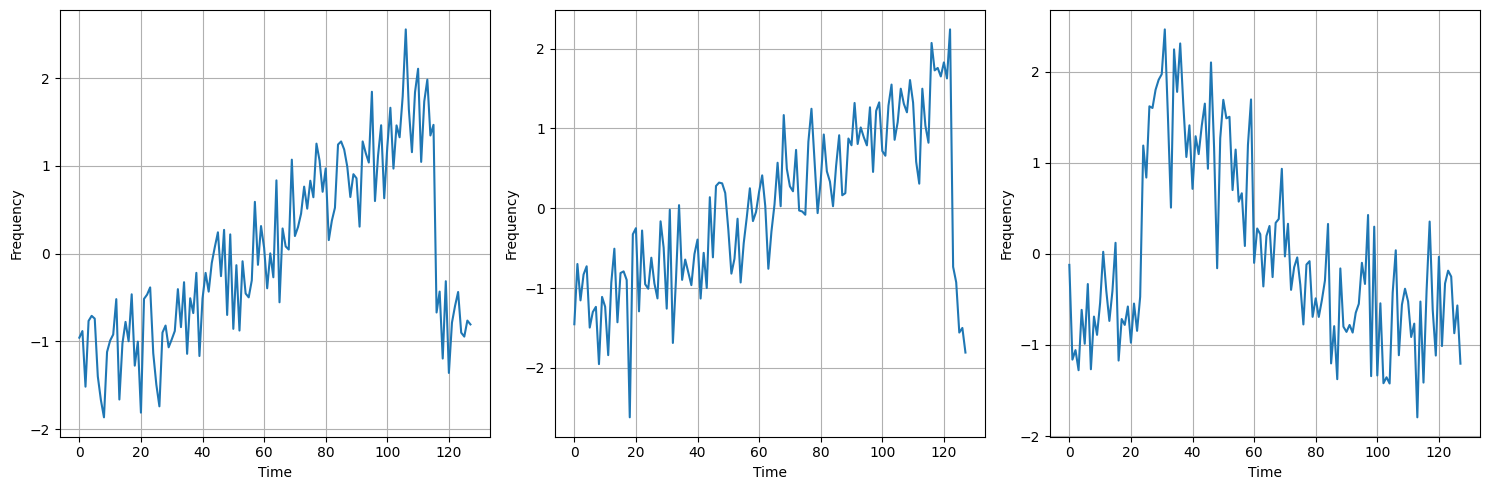

In [269]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

indices = [3, 4, 5]

for i, idx in enumerate(indices):
    axes[i].plot(X_train_scaled[idx])
    axes[i].set_xlabel("Time")
    axes[i].set_ylabel("Frequency")
    axes[i].grid(True)

plt.tight_layout()
plt.savefig("fig/Série a ser analisada")
plt.show()

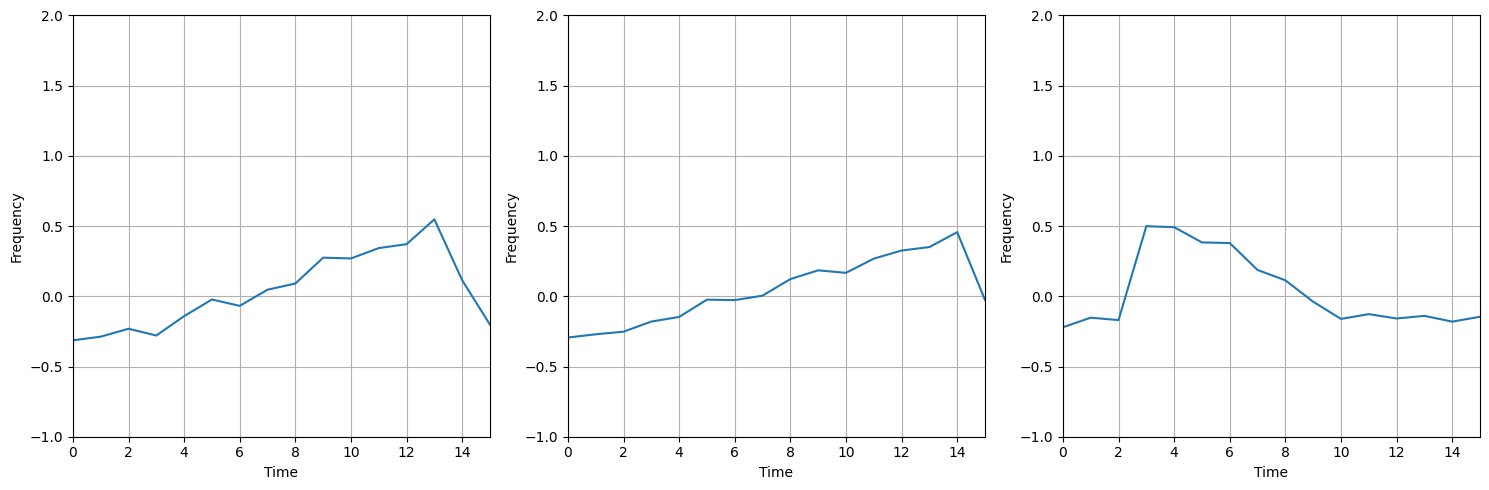

In [270]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

indices = [3, 4, 5]

for i, idx in enumerate(indices):
    axes[i].plot(encoded[idx])
    axes[i].set_xlabel("Time")
    axes[i].set_ylabel("Frequency")
    axes[i].grid(True)
    axes[i].set_xlim(0, X_train.shape[1] / modelo.pool_size - 1)
    axes[i].set_ylim(-1, 2)

plt.tight_layout()
plt.savefig("fig/Representação no espaço latente")
plt.show()



In [271]:
z_test = modelo.encoder.predict(X_test_scaled)
z_test_flat = z_test.reshape(z_test.shape[0], -1)
y_pred_test = modelo.kmeans.predict(z_test_flat)

y_aligned_test = np.array([mapping[c] for c in y_pred_test])
acc = (y_test == y_aligned_test).mean()
print("Test acc:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Test acc: 0.6666666666666666


In [272]:
print("Train:", np.unique(y_train_aug, return_counts=True))
print("Val:",   np.unique(y_val, return_counts=True))
print("Test:",  np.unique(y_test, return_counts=True))

Train: (array([1, 2, 3]), array([474, 482, 484]))
Val: (array([1, 2, 3]), array([63, 57, 60]))
Test: (array([1, 2, 3]), array([10, 12,  8]))
